
# WSX solenoid — G4BL vs OPALX

The same 13 particles go through the same field map in both codes; this compares the
two outputs particle by particle.

**Frame:** `z` in `wsx_solenoid.g4bl` [mm] / 1000 == path length `s` in
`wsx_solenoid.in` [m], exactly. Field spans 300–3300 mm, recording planes at 150 and
3450 mm, both in field-free drift.

Order of use:
1. Run **Setup** and **Write the particle files** below.
2. Run both codes (commands in the cell after that).
3. Run everything from **Readers** down.


## Setup


In [12]:

import subprocess, sys
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

HERE = Path.cwd()
ROOT = HERE.parents[3]                      # /Users/rammann/Code/OPALX
sys.path.insert(0, str(ROOT / "runs" / "processing"))
from opalx_diagnostics import parse_opal_stat   # noqa: E402

# --- physics constants -------------------------------------------------------
MU_MASS   = 0.1056583755          # GeV
MU_MASS_MEV = MU_MASS * 1e3       # MeV
P0        = 0.028                 # GeV/c   (g4bl referenceMomentum=28)
BG0       = P0 / MU_MASS          # beta*gamma
GAMMA0    = np.sqrt(1.0 + BG0**2)
BETA0     = BG0 / GAMMA0
BRHO      = P0 / 0.299792458      # T*m
C_MM_PER_NS = 299.792458

# --- geometry ----------------------------------------------------------------
Z_IN_MM, Z_OUT_MM = 150.0, 3450.0          # recording planes, both codes

# --- pencil-set step sizes ---------------------------------------------------
EPS = dict(x=1e-3, xp=1e-3, y=1e-3, yp=1e-3, z=1e-3, d=1e-3)   # m, rad, m, -

# index pairs (plus, minus) for the finite-difference transfer map, in the
# canonical coordinate order (x, x', y, y', zeta, delta)
PAIRS  = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12)]
LABELS = ["x", "x'", "y", "y'", "zeta", "delta"]

print(f"beta*gamma = {BG0:.7f}   beta = {BETA0:.7f}   gamma = {GAMMA0:.7f}")
print(f"beta*c     = {BETA0 * C_MM_PER_NS:.4f} mm/ns")
print(f"Brho       = {BRHO:.6f} T*m")


beta*gamma = 0.2650050   beta = 0.2561628   gamma = 1.0345181
beta*c     = 76.7957 mm/ns
Brho       = 0.093398 T*m



## Write the particle files

Reference plus a ± step in each of the 6 phase-space coordinates. One array, two
encodings, so the codes cannot be fed different particles.

The set is **exactly symmetric in ±** on purpose: OPALX under `FROMFILE` takes its
reference orbit from the bunch *mean*, and symmetry is what makes that mean coincide
with G4BL's `reference particle=mu+ referenceMomentum=28`. Adding one asymmetric
particle would put a silent offset into every transverse comparison.


In [13]:

def pencil_set():
    # 13 rows of (x, y, z [m], px, py, pz [beta*gamma]); row 0 is the reference.
    rows = []
    def row(x=0.0, y=0.0, z=0.0, px=0.0, py=0.0, pz=BG0):
        rows.append((x, y, z, px, py, pz))

    row()                                                    # 0  reference
    row(x=+EPS["x"]);            row(x=-EPS["x"])            # 1,2
    row(px=+EPS["xp"] * BG0);    row(px=-EPS["xp"] * BG0)    # 3,4   x' = px/pz
    row(y=+EPS["y"]);            row(y=-EPS["y"])            # 5,6
    row(py=+EPS["yp"] * BG0);    row(py=-EPS["yp"] * BG0)    # 7,8
    row(z=+EPS["z"]);            row(z=-EPS["z"])            # 9,10
    row(pz=BG0 * (1 + EPS["d"])); row(pz=BG0 * (1 - EPS["d"]))  # 11,12
    return np.array(rows)


P = pencil_set()

# the symmetry that pins the OPALX reference orbit
mean_R, mean_P = P[:, :3].mean(axis=0), P[:, 3:].mean(axis=0)
assert np.allclose(mean_R, 0, atol=1e-15), mean_R
assert np.allclose(mean_P, [0, 0, BG0], atol=1e-15), mean_P
print("mean R =", mean_R, "   mean P =", mean_P, "  (must be 0,0,0 and 0,0,BG0)")

# --- parts.txt : OPALX FROMFILE  (m, beta*gamma) ------------------------------
with open("parts.txt", "w") as f:
    f.write(f"{len(P)}\n")
    f.write("x px y py z pz\n")
    for x, y, z, px, py, pz in P:
        f.write(" ".join(f"{v:.12e}" for v in (x, px, y, py, z, pz)) + "\n")

# --- beam.txt : G4BL BLTrackFile  (mm, MeV/c, ns) -----------------------------
# EventID = row + 1, so EventID == OPALX id + 1.
with open("beam.txt", "w") as f:
    f.write("#BLTrackFile g4bl_compare pencil set\n")
    f.write("#x y z Px Py Pz t PDGid EventID TrackID ParentID Weight\n")
    f.write("#mm mm mm MeV/c MeV/c MeV/c ns - - - - -\n")
    for i, (x, y, z, px, py, pz) in enumerate(P):
        f.write(
            f"{x*1e3:.9g} {y*1e3:.9g} {z*1e3:.9g} "
            f"{px*MU_MASS_MEV:.9g} {py*MU_MASS_MEV:.9g} {pz*MU_MASS_MEV:.9g} "
            f"0 -13 {i+1} 1 0 1\n"
        )

print("wrote parts.txt and beam.txt")
print(open("beam.txt").read())


mean R = [0. 0. 0.]    mean P = [0.         0.         0.26500502]   (must be 0,0,0 and 0,0,BG0)
wrote parts.txt and beam.txt
#BLTrackFile g4bl_compare pencil set
#x y z Px Py Pz t PDGid EventID TrackID ParentID Weight
#mm mm mm MeV/c MeV/c MeV/c ns - - - - -
0 0 0 0 0 28 0 -13 1 1 0 1
1 0 0 0 0 28 0 -13 2 1 0 1
-1 0 0 0 0 28 0 -13 3 1 0 1
0 0 0 0.028 0 28 0 -13 4 1 0 1
0 0 0 -0.028 0 28 0 -13 5 1 0 1
0 1 0 0 0 28 0 -13 6 1 0 1
0 -1 0 0 0 28 0 -13 7 1 0 1
0 0 0 0 0.028 28 0 -13 8 1 0 1
0 0 0 0 -0.028 28 0 -13 9 1 0 1
0 0 1 0 0 28 0 -13 10 1 0 1
0 0 -1 0 0 28 0 -13 11 1 0 1
0 0 0 0 0 28.028 0 -13 12 1 0 1
0 0 0 0 0 27.972 0 -13 13 1 0 1




## Run both codes

```bash
cd opalx-runs/studies/g4bl_compare/wsx_solenoid

source /Users/rammann/Code/G4BL/G4beamline-3.08.app/Contents/root/bin/thisroot.sh
g4bl wsx_solenoid.g4bl > g4bl.log 2>&1

mpirun -n 1 <opalx> wsx_solenoid.in --info 1 > run.log 2>&1
```

One MPI rank only — particle-to-row identity across ranks isn't guaranteed. The cell
below runs both for you if the binaries are where they normally are.


In [14]:

G4BL_APP  = Path("/Users/rammann/Code/G4BL/G4beamline-3.08.app")
OPALX_CANDIDATES = [ROOT / "build/src/opalx",
                    ROOT / "opalx/build_serial/src/opalx",
                    ROOT / "opalx/build/src/opalx"]


def run_g4bl():
    g4bl = G4BL_APP / "Contents/MacOS/g4bl"
    if not g4bl.is_file():
        raise FileNotFoundError(g4bl)
    for stale in ("Z150.txt", "Z3450.txt", "g4bl_axis.txt", "g4bl.log"):
        Path(stale).unlink(missing_ok=True)
    cmd = (f'source "{G4BL_APP}/Contents/root/bin/thisroot.sh" && '
           f'"{g4bl}" wsx_solenoid.g4bl')
    r = subprocess.run(["bash", "-c", cmd], capture_output=True, text=True)
    Path("g4bl.log").write_text(r.stdout + r.stderr)
    print("g4bl rc =", r.returncode, "-> g4bl.log")
    return r.returncode


def run_opalx():
    opalx = next((c for c in OPALX_CANDIDATES if c.is_file()), None)
    if opalx is None:
        raise FileNotFoundError(f"no opalx binary under {ROOT}")
    for stale in ("MON_IN.h5", "MON_OUT.h5", "wsx_solenoid.h5", "wsx_solenoid.stat"):
        Path(stale).unlink(missing_ok=True)
    r = subprocess.run(["mpirun", "-n", "1", str(opalx), "wsx_solenoid.in", "--info", "1"],
                       capture_output=True, text=True)
    Path("run.log").write_text(r.stdout + r.stderr)
    print("opalx rc =", r.returncode, "->", opalx, "-> run.log")
    return r.returncode


run_g4bl()
run_opalx()


g4bl rc = 0 -> g4bl.log
opalx rc = 156 -> /Users/rammann/Code/OPALX/build/src/opalx -> run.log


156

## Readers


In [15]:

BLTRACK_COLS = ["x", "y", "z", "Px", "Py", "Pz", "t",
                "PDGid", "EventID", "TrackID", "ParentID", "Weight"]


def read_bltrack(path):
    # G4BL ASCII ntuple (#BLTrackFile). mm, MeV/c, ns. -> dict of arrays.
    data = np.loadtxt(path, comments="#", ndmin=2)
    return {name: data[:, i] for i, name in enumerate(BLTRACK_COLS[:data.shape[1]])}


def read_monitor(path):
    # OPALX MONITOR .h5, in m / beta*gamma / seconds. Particles arrive over
    # several tracking steps, so every Step#N group has to be concatenated.
    keys = ["id", "x", "y", "z", "px", "py", "pz", "time"]
    out = {k: [] for k in keys}
    with h5py.File(path, "r") as f:
        for g in sorted(f.keys(), key=lambda s: int(s.split("#")[1])):
            for k in keys:
                out[k].append(np.asarray(f[g][k]))
    out = {k: np.concatenate(v) for k, v in out.items()}
    o = np.argsort(out["id"])
    return {k: v[o] for k, v in out.items()}


def read_field_axis(path):
    # G4BL fieldntuple: x y z t Bx By Bz Ex Ey Ez, in mm / ns / tesla.
    d = np.loadtxt(path, comments="#", ndmin=2)
    return d[:, 2], d[:, 6]        # z [mm], Bz [T]



## Canonical coordinates

Both codes are reduced to the same 6-vector per particle, in the same row order as
`parts.txt`:

$$X = (x,\; x' = p_x/p_z,\; y,\; y',\; \zeta = -\beta_0 c\,(t - t_0),\; \delta = |p|/p_0 - 1)$$

with lengths in **m** and angles in **rad**. \(t_0\) is the arrival time of particle 0
(the on-axis reference) at that same plane — the one quantity both codes give directly.

`x'` and `y'` are the primary comparison: they're ratios of momenta, so they don't care
about either code's frame convention.


In [16]:

def canon_g4bl(d):
    n = len(d["x"])
    idx = np.argsort(d["EventID"])
    x  = d["x"][idx] * 1e-3
    y  = d["y"][idx] * 1e-3
    px = d["Px"][idx] / MU_MASS_MEV
    py = d["Py"][idx] / MU_MASS_MEV
    pz = d["Pz"][idx] / MU_MASS_MEV
    t  = d["t"][idx]                                   # ns
    zeta  = -BETA0 * C_MM_PER_NS * (t - t[0]) * 1e-3   # mm -> m
    delta = np.sqrt(px**2 + py**2 + pz**2) / BG0 - 1.0
    return np.vstack([x, px / pz, y, py / pz, zeta, delta]), d["EventID"][idx].astype(int)


def canon_opalx(d):
    px, py, pz = d["px"], d["py"], d["pz"]
    t = d["time"] * 1e9                                # s -> ns
    zeta  = -BETA0 * C_MM_PER_NS * (t - t[0]) * 1e-3
    delta = np.sqrt(px**2 + py**2 + pz**2) / BG0 - 1.0
    return np.vstack([d["x"], px / pz, d["y"], py / pz, zeta, delta]), d["id"].astype(int)


g_in,  g_out  = read_bltrack("Z150.txt"),  read_bltrack("Z3450.txt")
o_in,  o_out  = read_monitor("MON_IN.h5"), read_monitor("MON_OUT.h5")

Xg_in, id_g_in  = canon_g4bl(g_in)
Xg_out, id_g_out = canon_g4bl(g_out)
Xo_in, id_o_in  = canon_opalx(o_in)
Xo_out, id_o_out = canon_opalx(o_out)

# --- sanity: nothing lost, and the two codes are talking about the same particles
print(f"G4BL   Z150 {Xg_in.shape[1]:3d}   Z3450 {Xg_out.shape[1]:3d}")
print(f"OPALX  MON_IN {Xo_in.shape[1]:3d}   MON_OUT {Xo_out.shape[1]:3d}")
for nm, ids, expect in [("g4bl in", id_g_in, np.arange(1, 14)),
                        ("g4bl out", id_g_out, np.arange(1, 14)),
                        ("opalx in", id_o_in, np.arange(0, 13)),
                        ("opalx out", id_o_out, np.arange(0, 13))]:
    ok = len(ids) == len(expect) and np.array_equal(ids, expect)
    print(f"  {nm:10s} ids {'OK' if ok else 'MISMATCH: ' + str(ids)}")
print("\n(G4BL EventID == OPALX id + 1 by construction)")


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'MON_IN.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Per-particle comparison at the exit plane


In [ ]:

def diff_table(Xg, Xo, title):
    D = Xo - Xg
    print(title)
    print(f"{'#':>3} {'coord':>6} "
          f"{'G4BL':>14} {'OPALX':>14} {'diff':>12}")
    print("-" * 66)
    for j in range(Xg.shape[1]):
        for i, lab in enumerate(LABELS):
            print(f"{j:>3} {lab:>6} {Xg[i, j]:>14.6e} {Xo[i, j]:>14.6e} {D[i, j]:>12.3e}")
        print()
    print("max |diff| per coordinate:")
    for i, lab in enumerate(LABELS):
        unit = "m" if lab in ("x", "y", "zeta") else ("rad" if "'" in lab else "-")
        print(f"  {lab:>6} {np.abs(D[i]).max():.3e} {unit}")
    return D


D_out = diff_table(Xg_out, Xo_out, "exit plane z = 3450 mm  (OPALX - G4BL)")


NameError: name 'Xg_out' is not defined

In [ ]:

# The same at the entrance plane -- this one is pure plumbing: both codes should
# reproduce the input file, so a nonzero difference here means the two codes were
# not fed the same particles.
print("entrance plane z = 150 mm  (OPALX - G4BL), max |diff| per coordinate:")
D_in = Xo_in - Xg_in
for i, lab in enumerate(LABELS):
    print(f"  {lab:>6} {np.abs(D_in[i]).max():.3e}")
print("\nG4BL ASCII output is %.6g -- 6 significant digits -- so ~5e-7 relative is")
print("the floor for every number here.")


entrance plane z = 150 mm  (OPALX - G4BL), max |diff| per coordinate:


NameError: name 'Xo_in' is not defined


## Transfer matrices

6×6 map from the 150 mm plane to the 3450 mm plane, by centered finite differences
over the ± pairs. Measured the same way from each code, so they're directly comparable.


In [ ]:

def transfer_map(Xin, Xout):
    din  = np.column_stack([(Xin[:, p] - Xin[:, m]) / 2.0 for p, m in PAIRS])
    dout = np.column_stack([(Xout[:, p] - Xout[:, m]) / 2.0 for p, m in PAIRS])
    return dout @ np.linalg.inv(din)


Mg = transfer_map(Xg_in, Xg_out)
Mo = transfer_map(Xo_in, Xo_out)


def print_two(A, B, na, nb):
    print(f"{'':>6}" + "".join(f"{l:>12}" for l in LABELS) + "     |" +
          "".join(f"{l:>12}" for l in LABELS))
    print(f"{'':>6}{na:>72}     |{nb:>72}")
    for i in range(6):
        ra = "".join(f"{A[i, j]:>12.5f}" for j in range(6))
        rb = "".join(f"{B[i, j]:>12.5f}" for j in range(6))
        print(f"{LABELS[i]:>6}{ra}     |{rb}")


print_two(Mg, Mo, "G4BL", "OPALX")
print()
Md = Mo - Mg
print("OPALX - G4BL, element-wise:")
for i in range(6):
    print(f"{LABELS[i]:>6}" + "".join(f"{Md[i, j]:>12.2e}" for j in range(6)))
print(f"\nmax |element difference| = {np.abs(Md).max():.3e}")

J = np.zeros((6, 6))
for k in range(3):
    J[2 * k, 2 * k + 1], J[2 * k + 1, 2 * k] = 1.0, -1.0
for nm, M in (("G4BL", Mg), ("OPALX", Mo)):
    print(f"{nm:6s} symplectic residual max|M^T J M - J| = "
          f"{np.abs(M.T @ J @ M - J).max():.3e}")
print("\n(zeta and delta as defined here are conjugate only up to a factor, and the")
print(" finite-difference steps are 1e-3, so a residual of order 1e-3 is the method,")
print(" not the code. Compare the two codes' residuals to each other, not to zero.)")


NameError: name 'Xg_in' is not defined


## Larmor rotation

A solenoid's 4×4 block is a rotation by $\theta_L$ applied to a common 2×2:

$$M_{4\times4} = \begin{pmatrix} \cos\theta_L\,M_2 & \sin\theta_L\,M_2 \\ -\sin\theta_L\,M_2 & \cos\theta_L\,M_2\end{pmatrix},
\qquad \theta_L = \frac{\int B_z\,ds}{2B\rho}$$

**The sign matters.** `place MAG z=1800 rotation=Y180` is a 180° rotation about y,
$R = \mathrm{diag}(-1, 1, -1)$, so it mirrors the map in z *and* flips the sign of $B_z$:
$B_z^{\text{lab}}(z) = -B_z^{\text{map}}(z_{\text{place}} - z)$, with $B_r$ unchanged. The
map is strongly asymmetric in z, so this is the sharpest check that both codes agree on
what the placement means.


In [ ]:

def larmor_from_matrix(M):
    # M[0:2,0:2] = cos(th)*A and M[2:4,0:2] = -sin(th)*A for a common 2x2 A, so
    # atan2 gives th only modulo pi -- the two branches differ by A -> -A. The
    # branch is fixed by requiring A[0,1] > 0, i.e. a net-drifting channel.
    # (That holds while the Larmor phase advance is below pi, which it is here;
    # a much stronger solenoid would need a different discriminant.)
    Mxx, Myx = M[0:2, 0:2], M[2:4, 0:2]
    th0 = np.arctan2(-M[2, 0], M[0, 0])
    for th in (th0, th0 - np.copysign(np.pi, th0)):
        A = np.cos(th) * Mxx - np.sin(th) * Myx
        if A[0, 1] > 0:
            return th
    return th0


z_ax, bz_ax = read_field_axis("g4bl_axis.txt")
int_bz = np.trapezoid(bz_ax, z_ax * 1e-3) if hasattr(np, "trapezoid") \
         else np.trapz(bz_ax, z_ax * 1e-3)
theta_field = int_bz / (2 * BRHO)

# matrix-free cross-check: the x+ particle, rotated about the axis
theta_traj_g = np.arctan2(Xg_out[2, 1], Xg_out[0, 1])
theta_traj_o = np.arctan2(Xo_out[2, 1], Xo_out[0, 1])

print(f"peak |Bz| on axis        {np.abs(bz_ax).max():.6f} T "
      f"at z = {z_ax[np.abs(bz_ax).argmax()]:.0f} mm")
print(f"int Bz dz                {int_bz:+.6f} T*m")
print()
print(f"theta from field         {theta_field:+.6f} rad  ({np.degrees(theta_field):+.3f} deg)")
print(f"theta from G4BL  matrix  {larmor_from_matrix(Mg):+.6f} rad")
print(f"theta from OPALX matrix  {larmor_from_matrix(Mo):+.6f} rad")
print(f"theta from G4BL  x+ traj {theta_traj_g:+.6f} rad   (+-pi ambiguous: the x+")
print(f"theta from OPALX x+ traj {theta_traj_o:+.6f} rad    particle crosses the axis)")
print()
print(f"OPALX - G4BL (matrix)    {larmor_from_matrix(Mo) - larmor_from_matrix(Mg):+.3e} rad")


NameError: name 'Xg_out' is not defined


## Field import check

OPALX's `Bz_ref` from the `.stat` file is the field on the reference particle, which
sits on the axis here — so it's directly comparable to G4BL's on-axis `fieldntuple` dump.
**No tracking physics is involved in this comparison**, so a mismatch here is a field-map
plumbing problem, not a physics disagreement, and everything below it is meaningless
until it passes.


In [ ]:

meta, st = parse_opal_stat("wsx_solenoid.stat")
s_opalx, bz_opalx = st["s"].to_numpy(), st["Bz_ref"].to_numpy()

# g4bl z [mm] / 1000 == opalx s [m], by construction
bz_g4bl_at_s = np.interp(s_opalx, z_ax * 1e-3, bz_ax, left=np.nan, right=np.nan)
ok = np.isfinite(bz_g4bl_at_s)
dbz = bz_opalx[ok] - bz_g4bl_at_s[ok]

print(f"samples compared          {ok.sum()}")
print(f"peak |Bz| OPALX           {np.abs(bz_opalx).max():.6f} T "
      f"at s = {s_opalx[np.abs(bz_opalx).argmax()]:.3f} m")
print(f"peak |Bz| G4BL            {np.abs(bz_ax).max():.6f} T "
      f"at z = {z_ax[np.abs(bz_ax).argmax()] * 1e-3:.3f} m")
print(f"max |Bz_OPALX - Bz_G4BL|  {np.abs(dbz).max():.3e} T "
      f"({np.abs(dbz).max() / np.abs(bz_ax).max():.2e} of peak)")

int_bz_opalx = np.trapezoid(bz_opalx, s_opalx) if hasattr(np, "trapezoid") \
               else np.trapz(bz_opalx, s_opalx)
print(f"int Bz ds  OPALX          {int_bz_opalx:+.6f} T*m")
print(f"int Bz ds  G4BL           {int_bz:+.6f} T*m")


FileNotFoundError: [Errno 2] No such file or directory: 'wsx_solenoid.stat'

## Plots


NameError: name 's_opalx' is not defined

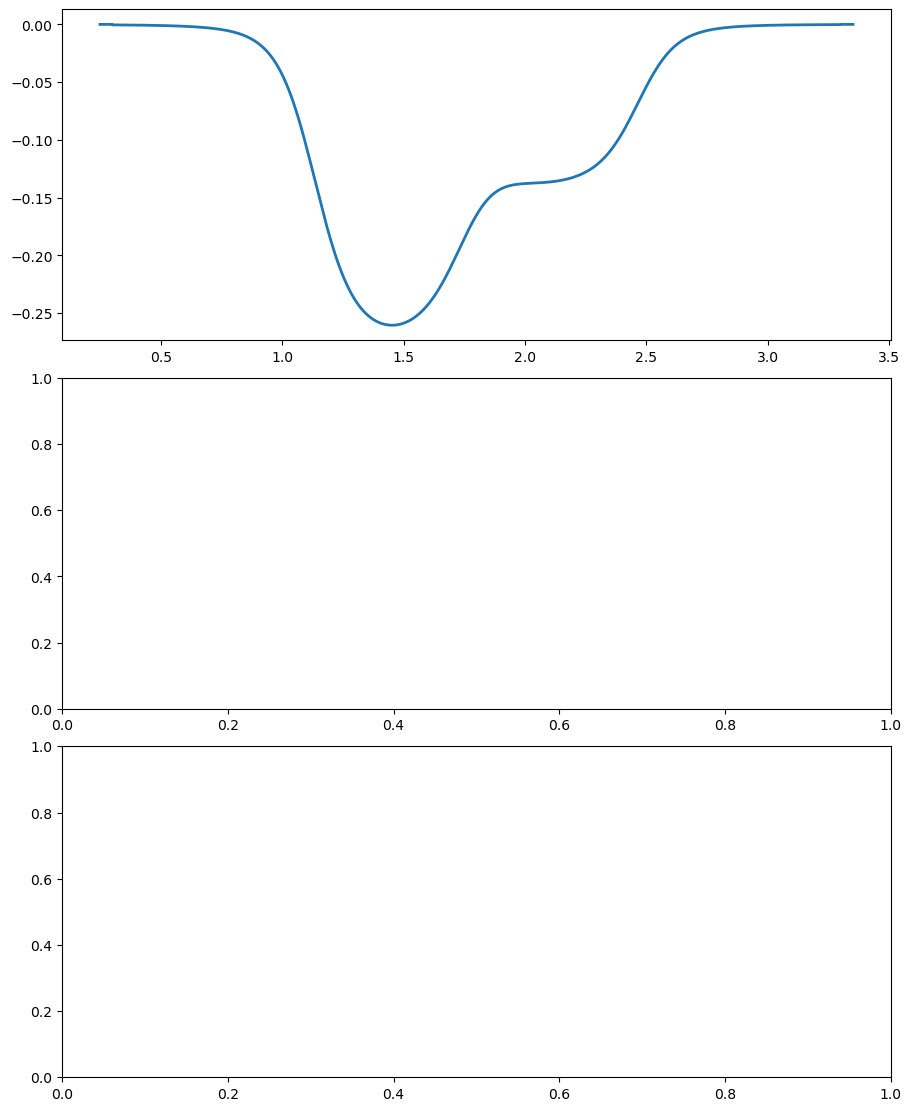

In [ ]:

fig, ax = plt.subplots(3, 1, figsize=(9, 11), constrained_layout=True)

ax[0].plot(z_ax * 1e-3, bz_ax, label="G4BL fieldntuple", lw=2)
ax[0].plot(s_opalx, bz_opalx, "--", label="OPALX Bz_ref", lw=1.5)
ax[0].set_xlabel("s [m]"); ax[0].set_ylabel("Bz on axis [T]")
ax[0].set_title("on-axis field"); ax[0].legend(); ax[0].grid(alpha=.3)

w = 0.35
j = np.arange(Xg_out.shape[1])
ax[1].bar(j - w/2, Xg_out[0] * 1e3, w, label="G4BL")
ax[1].bar(j + w/2, Xo_out[0] * 1e3, w, label="OPALX")
ax[1].set_xlabel("particle"); ax[1].set_ylabel("x at exit [mm]")
ax[1].set_title("exit x"); ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(Xg_out[0] * 1e3, Xg_out[2] * 1e3, "o", ms=8, label="G4BL")
ax[2].plot(Xo_out[0] * 1e3, Xo_out[2] * 1e3, "x", ms=8, mew=2, label="OPALX")
ax[2].set_xlabel("x [mm]"); ax[2].set_ylabel("y [mm]")
ax[2].set_title("exit plane x-y (the Larmor rotation is visible here)")
ax[2].set_aspect("equal"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.show()
